# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: TrigonometricEmbedding (p=2)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [1]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
import jax.numpy as jnp
import numpy as np
import optax
from sklearn.metrics import auc
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from jax.nn.initializers import *
import matplotlib.pyplot as plt
import h5py

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *

2025-05-02 08:21:12.748400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746199272.978633 2306763 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746199273.009053 2306763 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746199273.383979 2306763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746199273.384011 2306763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746199273.384013 2306763 computation_placer.cc:177] computation placer alr

In [2]:
jax.config.update("jax_enable_x64", True)

**Load 40 MHz dataset**

In [3]:
from hep_data import *
inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/"
h5_file = h5py.File(inputPath+"background_for_training.h5", 'r')

dataset = create_tf_dataset(h5_file, 'Particles', batch_size=64)

I0000 00:00:1746199579.125805 2306763 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0


In [4]:
# Apply the transformation using a lambda function with transposed structure
structured_dataset = dataset.map(lambda batch: {
    'MET': {
        'pt': tf.transpose(batch[:, 0:1, 0], [1, 0]),    # Shape: (1, batch_size)
        # 'eta': tf.transpose(batch[:, 0:1, 1], [1, 0]),   # Shape: (1, batch_size)
        'phi': tf.transpose(batch[:, 0:1, 2], [1, 0]),   # Shape: (1, batch_size)
    },
    'Ele': {
        'pt': tf.transpose(batch[:, 1:5, 0], [1, 0]),    # Shape: (4, batch_size)
        'eta': tf.transpose(batch[:, 1:5, 1], [1, 0]),   # Shape: (4, batch_size)
        'phi': tf.transpose(batch[:, 1:5, 2], [1, 0]),   # Shape: (4, batch_size)
    },
    'Mu': {
        'pt': tf.transpose(batch[:, 5:9, 0], [1, 0]),    # Shape: (4, batch_size)
        'eta': tf.transpose(batch[:, 5:9, 1], [1, 0]),   # Shape: (4, batch_size)
        'phi': tf.transpose(batch[:, 5:9, 2], [1, 0]),   # Shape: (4, batch_size)
    },
    'Jet': {
        'pt': tf.transpose(batch[:, 9:19, 0], [1, 0]),   # Shape: (10, batch_size)
        'eta': tf.transpose(batch[:, 9:19, 1], [1, 0]),  # Shape: (10, batch_size)
        'phi': tf.transpose(batch[:, 9:19, 2], [1, 0]),  # Shape: (10, batch_size)
    }
})

In [7]:
# Test the resulting dataset
for batch_dict in structured_dataset.take(1):
    print("MET pt shape:", batch_dict['MET']['pt'].shape)
    print("Ele eta shape:", batch_dict['Ele']['eta'].shape)
    print("Mu phi shape:", batch_dict['Mu']['phi'].shape)
    print("Jet pt shape:", batch_dict['Jet']['pt'].shape)
    
    # Print a sample from each category
    print("\nLeading MET pt:")
    print(batch_dict['MET']['pt'][0])  # First MET across batch
    
    print("\nLeading Electron pt:")
    print(batch_dict['Ele']['pt'][0])  # First electron eta across batch
    
    print("\nLeading Muon phi:")
    print(batch_dict['Mu']['phi'][0])  # First muon phi across batch
    
    print("\nLeading Jet pt:")
    print(batch_dict['Jet']['pt'][0])  # First jet pt across batch

MET pt shape: (1, 64)
Ele eta shape: (4, 64)
Mu phi shape: (4, 64)
Jet pt shape: (10, 64)

Leading MET pt:
tf.Tensor(
[16.92448807 38.93186569 70.63088989 27.51575661 81.83081818 21.62716484
 31.55674553 21.59561539 45.51780701 29.28074074 24.11700058 63.69463348
 21.34718513 41.18844604 56.70212555 36.71451569 60.10429382 38.80770874
 18.02309799 10.51683903 47.37843704 43.72516251 35.87258148 25.50764465
 61.12104416 47.13877487  5.84902763 37.7195549  50.7440834  23.940979
 26.57659721 29.81521225 31.93525124 28.91404533 20.07905579 50.91516876
 39.49405289  1.27168393 24.64440727 28.70557785 26.29039574 25.42818069
 67.87213898 49.35802078  9.26696491 46.69301605 64.34358978 48.27397156
 23.49433517 55.25398636 39.29781342 32.6455574  27.36640167  5.60402107
 51.18050385 28.70663452 55.23906326 80.17565155 26.74078178 24.26525307
 44.95215225 31.27610588 53.46660995 37.07183456], shape=(64,), dtype=float64)

Leading Electron pt:
tf.Tensor(
[ 0.         42.83616638 43.17228317 27.88

In [6]:
#**Optional block to create plots of all features**

SyntaxError: invalid syntax (3525398202.py, line 1)

In [44]:
# Create output directory
output_dir = "feature_plots"
os.makedirs(output_dir, exist_ok=True)

# Function to collect data from multiple batches
def collect_data(dataset, max_batches):
    data = {
        'MET': {'pt': [], 'phi': []},
        'Ele': {'pt': [], 'eta': [], 'phi': []},
        'Mu': {'pt': [], 'eta': [], 'phi': []},
        'Jet': {'pt': [], 'eta': [], 'phi': []}
    }
    
    for i, batch_dict in enumerate(dataset):
        if i >= max_batches:
            break
            
        # MET
        data['MET']['pt'].append(batch_dict['MET']['pt'][0].numpy())
        data['MET']['phi'].append(batch_dict['MET']['phi'][0].numpy())
        
        # Electrons
        for j in range(4):
            data['Ele']['pt'].append(batch_dict['Ele']['pt'][j].numpy())
            data['Ele']['eta'].append(batch_dict['Ele']['eta'][j].numpy())
            data['Ele']['phi'].append(batch_dict['Ele']['phi'][j].numpy())
        
        # Muons
        for j in range(4):
            data['Mu']['pt'].append(batch_dict['Mu']['pt'][j].numpy())
            data['Mu']['eta'].append(batch_dict['Mu']['eta'][j].numpy())
            data['Mu']['phi'].append(batch_dict['Mu']['phi'][j].numpy())
        
        # Jets
        for j in range(10):
            data['Jet']['pt'].append(batch_dict['Jet']['pt'][j].numpy())
            data['Jet']['eta'].append(batch_dict['Jet']['eta'][j].numpy())
            data['Jet']['phi'].append(batch_dict['Jet']['phi'][j].numpy())
    
    # Concatenate all batches
    for particle in data:
        for feature in data[particle]:
            data[particle][feature] = np.concatenate(data[particle][feature])
    
    return data

# Collect data from half the dataset
total_batches = sum(1 for _ in structured_dataset)
data = collect_data(structured_dataset, max_batches=total_batches//2)

<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_76312/430807167.py:56: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$ [no units]',
/tmp/ipykernel_76312/430807167.py:57: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'
/tmp/ipykernel_76312/430807167.py:56: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$ [no units]',
/tmp/ipykernel_76312/430807167.py:57: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'


NameError: name 'plot' is not defined

<Figure size 1000x600 with 0 Axes>

In [50]:
# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'MET': 'crimson', 'Ele': 'royalblue', 'Mu': 'forestgreen', 'Jet': 'darkorange'}
labels = {
    'pt': 'p$_T$ [GeV]', 
    'eta': '$\eta$', 
    'phi': '$\phi$ [rad]'
}

# Create plots for each feature
for particle in data:
    for feature in data[particle]:
        values = data[particle][feature]
        
        plt.figure(figsize=(10, 6))
        plt.yscale('log')
        plt.ylim(1e-3, 10)  # Set y-axis range

        if feature == 'pt':
            counts, bins = np.histogram(values, bins=100, range=(0, 100))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.arange(0, 101, 10))
        elif feature == 'eta':
            counts, bins = np.histogram(values, bins=101, range=(-5, 5))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.arange(-5, 5.1, 1))
        elif feature == 'phi':
            counts, bins = np.histogram(values, bins=101, range=(-np.pi, np.pi))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.linspace(-np.pi, np.pi, 13), ["-π", "", "-2π/3", "", "-π/3", "", "0", "", "π/3", "", "2π/3", "", "π"])

        
        plt.title(f'{particle} {feature} Distribution', fontsize=16)
        plt.xlabel(labels[feature], fontsize=14)
        plt.ylabel('Events', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save figure
        filename = f"{output_dir}/{particle}_{feature}.png"
        plt.savefig(filename, dpi=150)
        plt.close()
        
        print(f"Saved plot to {filename}")

print(f"\nAll plots saved to '{output_dir}' directory")

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_76312/4138130867.py:6: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$',
/tmp/ipykernel_76312/4138130867.py:7: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'


Saved plot to feature_plots/MET_pt.png
Saved plot to feature_plots/MET_phi.png
Saved plot to feature_plots/Ele_pt.png
Saved plot to feature_plots/Ele_eta.png
Saved plot to feature_plots/Ele_phi.png
Saved plot to feature_plots/Mu_pt.png
Saved plot to feature_plots/Mu_eta.png
Saved plot to feature_plots/Mu_phi.png
Saved plot to feature_plots/Jet_pt.png
Saved plot to feature_plots/Jet_eta.png
Saved plot to feature_plots/Jet_phi.png

All plots saved to 'feature_plots' directory


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [42]:
# define model parameters
L = 56
initializer = gramschmidt('normal', 1e-1)
key = jax.random.key(42)
shape_method = 'noteven'
bond_dim = 10
phys_dim = (3,3) #This will have to be tuned. (2,2) corresponds to binary dataset.
spacing = 8
add_identity = True
boundary='obc'

In [43]:
model = SMPO_initialize(L=L,
                        initializer=initializer,
                        key=key,
                        shape_method=shape_method,
                        spacing=spacing,
                        bond_dim=bond_dim,
                        phys_dim=phys_dim,
                        cyclic=False,
                        compress=True,
                        add_identity=add_identity,
                        boundary=boundary)

In [44]:
alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [45]:
# define training parameters
epochs = 100
batch_size = 64
optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = PolynomialEmbedding(degree=2, n=1, include_bias=True)
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate)

In [ ]:
#Sagar:: This needs to be harmonized with the data structuring up above. Pretty redundant to do it twice.
def convert_to_train_format(batch_dict):
    # Initialize list to hold all features
    all_features = []
    
    # Add MET features (pt, phi)
    all_features.append(batch_dict['MET']['pt'])  # Shape: (1, batch_size)
    all_features.append(batch_dict['MET']['phi'])  # Shape: (1, batch_size)
    
    # Add Electron features
    all_features.append(batch_dict['Ele']['pt'])  # Shape: (4, batch_size)
    all_features.append(batch_dict['Ele']['eta'])  # Shape: (4, batch_size)
    all_features.append(batch_dict['Ele']['phi'])  # Shape: (4, batch_size)
    
    # Add Muon features
    all_features.append(batch_dict['Mu']['pt'])  # Shape: (4, batch_size)
    all_features.append(batch_dict['Mu']['eta'])  # Shape: (4, batch_size)
    all_features.append(batch_dict['Mu']['phi'])  # Shape: (4, batch_size)
    
    # Add Jet features
    all_features.append(batch_dict['Jet']['pt'])  # Shape: (10, batch_size)
    all_features.append(batch_dict['Jet']['eta'])  # Shape: (10, batch_size)
    all_features.append(batch_dict['Jet']['phi'])  # Shape: (10, batch_size)
    
    # Concatenate all features along first dimension
    # This will create a tensor of shape (56, batch_size)
    concatenated = tf.concat(all_features, axis=0)
    
    # Transpose to get (batch_size, 56) which is what the model expects
    train_format = tf.transpose(concatenated)
    
    # Convert to numpy array
    return train_format.numpy()

# Create a list to collect all batches
all_batches = []

# Process each batch in the dataset
for batch_dict in structured_dataset:
    batch_array = convert_to_train_format(batch_dict)
    all_batches.append(batch_array)

# Concatenate all batches into one array
train_normal = np.concatenate(all_batches, axis=0)

# Optional: If you need to convert to a specific dtype
train_normal = train_normal.astype(np.float64)

In [23]:
print("Train normal shape before:", train_normal.shape)


Train normal shape before: (4000000, 56)


In [24]:
subset_size = 10000  # Start with 10k samples
train_normal_subset = train_normal[:subset_size]

In [34]:
# Verify the embedding configuration
print(embedding.dim)  # Should match expected output dimension
print(embedding.input_dim)  # Should be 56 for your data

# Try a simpler embedding for testing
simple_embedding = PolynomialEmbedding(degree=1, n=56)  # Linear embedding

4
1


In [46]:
history = model.train(train_normal_subset,
            epochs=epochs,
            batch_size=batch_size,
            embedding = embedding,
            normalize=True,
            earlystop=earlystop,
            cache=True, # compiling loss function to use it multiple times
            dtype=jnp.float64)

epoch:  31%|███        31/100 , loss=922.7037 

Waiting for 1 epochs.


epoch:  33%|███▎       33/100 , loss=922.3893

Waiting for 1 epochs.


epoch:  34%|███▍       34/100 , loss=924.4441

...

epoch:  36%|███▌       36/100 , loss=925.5442

Waiting for 4 epochs.


epoch:  37%|███▋       37/100 , loss=926.3390

Training stopped by EarlyStopping on epoch: 32


epoch:  38%|███▊       38/100 , loss=926.8364


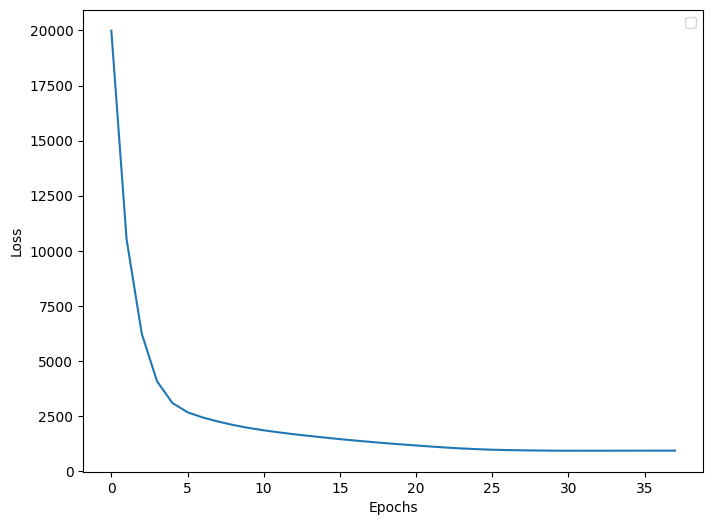

In [47]:
plot_loss(history, validation=False, figsize=(8, 6))

**Evaluate**

In [50]:
test_normal_subset = train_normal[subset_size:2*subset_size]

In [51]:
loss = LogQuadNorm

# anomaly_score = model.evaluate(test_anomaly, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=128, embedding=embedding, metric = loss)
normal_score_train = model.evaluate(train_normal_subset, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=64, embedding=embedding, metric = loss)
normal_score_test = model.evaluate(test_normal_subset, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=64, embedding=embedding, metric = loss)

**Plot anomaly scores and ROC curve**

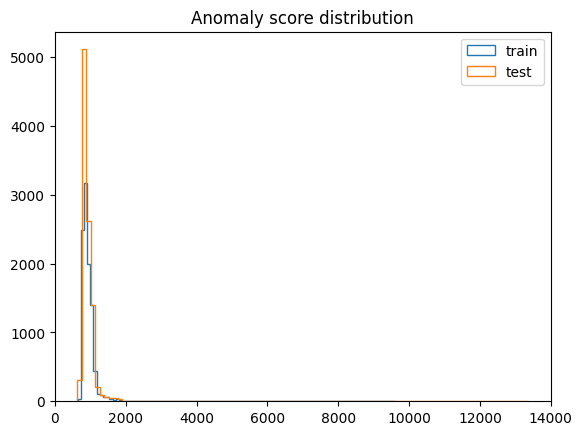

In [54]:
plt.figure()
# plt.hist(anomaly_score, bins=100, histtype='step', label='anomaly')
plt.hist(normal_score_train, bins=100, histtype='step', label='train')
plt.hist(normal_score_test, bins=100, histtype='step', label='test')
plt.title('Anomaly score distribution')
plt.legend()
# plt.text(0.5, -0.1, f'AUC Value: {auc_value}', ha='center', transform=plt.gca().transAxes)
plt.legend()
plt.show()

In [52]:
#Sagar:: This needs to be fixed after we include some signals in the evaluation
fpr, tpr = get_roc_curve_data(normal_score, anomaly_score, anomaly_det=True)
auc_value = auc(fpr, tpr)

NameError: name 'normal_score' is not defined

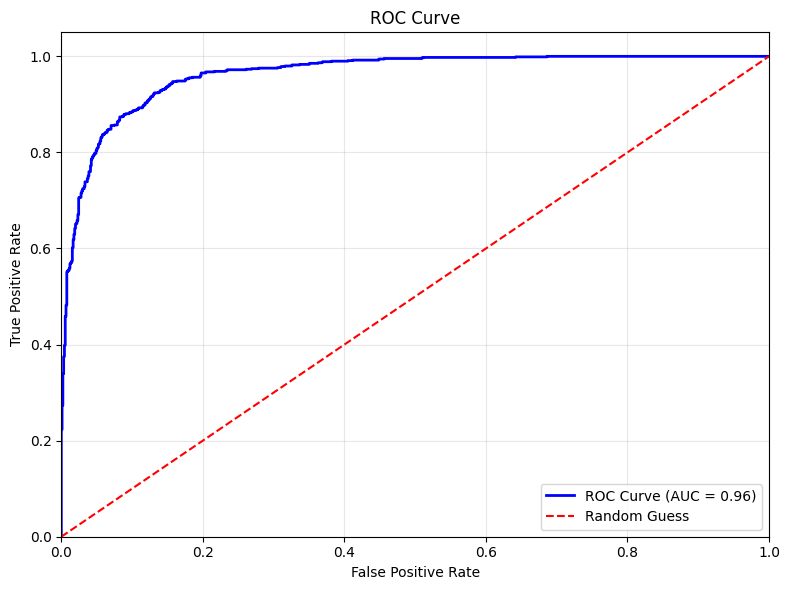

In [26]:
# Plot ROC curve
plot_ROC_curve_from_data(fpr, tpr)